## 이탈 위험 고객 클러스터링

### 목적
최종 LightGBM 모델이 예측한 **고객별 이탈 확률**을 활용하여 이탈 위험 고객을 선별하고, 이들의 결제·구독·서비스 이용 행동을 기준으로 유사한 고객끼리 군집화한다. 이를 통해 단순히 이탈 여부를 예측하는 것을 넘어, **이탈 위험 고객이 어떤 행동 특성을 가진 유형으로 나뉘는지 파악**하고 이후 유형별 Retention 전략 및 시뮬레이션으로 연결한다.

### 전체 파이프라인

**최종 이탈 예측 모델 불러오기**  
↓  
**Train + Test 전체 고객에 대해 이탈 확률(`churn_prob`) 산출**  
↓  
**최종 모델의 threshold를 기준으로 이탈 위험 고객 선별**  
↓  
**클러스터링 목적에 맞는 행동 특성 Feature 선정**  
↓  
**클러스터링용 데이터 전처리 및 Scaling**  
↓  
**여러 군집 수(K)에 대해 Clustering 수행**  
↓  
**Elbow Method / Silhouette Score + 해석 가능성을 고려하여 적절한 K 결정**  
↓  
**Cluster별 행동 특성 Profiling**  
↓  
**각 Cluster의 특징을 해석하여 고객 유형명 부여**  
↓  
**유형별 Retention 전략 및 What-if Simulation으로 확장**

### 1. 전체 고객 이탈 위험도 산출
- 저장된 최종 LightGBM 모델과 threshold를 불러온다.
- Train/Test에 동일한 피처 구조와 범주형 변수 기준을 적용한다.
- 전체 고객에 대해 이탈 확률(`churn_prob`)을 계산한다.
- 모델 성능 평가를 위한 Train/Test 구분과 별개로, 고객 유형 분석에서는 전체 고객을 분석 대상으로 활용한다.

### 2. 이탈 위험 고객 선별
- 최종 모델에서 결정한 threshold 이상인 고객을 **이탈 위험 고객군**으로 정의한다.
- 이후 클러스터링은 전체 고객이 아니라 이탈 위험 고객을 중심으로 수행한다.
- 분석 질문은 “전체 고객은 어떤 유형인가?”보다 **“이탈 가능성이 높은 고객들은 행동 특성에 따라 어떤 유형으로 나뉘는가?”**에 초점을 둔다.

### 3. 클러스터링 Feature 선정
- LightGBM에 사용된 모든 Feature를 그대로 사용하는 것이 아니라, **고객 행동 유형을 설명할 수 있는 변수**를 선별한다.
- 주요 관점은 다음과 같이 구성한다.
  - **서비스 활동성:** 활동 일수, 최근 이용 여부 등
  - **서비스 이용 강도:** 평균 이용 시간, 콘텐츠 이용량 등
  - **결제 특성:** 평균 결제금액, 단위 기간당 결제금액 등
  - **구독 특성:** 구독 기간, 자동갱신 여부 등
  - **고객 관계:** 가입 기간, 거래 횟수 등
- `churn_prob`는 초기 클러스터링 Feature에서는 제외하고, 군집 생성 후 **각 Cluster의 위험 수준을 해석하는 Profiling 지표**로 활용한다.

### 4. 클러스터링 전처리
- 선택한 Feature들의 결측치와 분포를 확인한다.
- 변수마다 단위와 범위가 다르므로 거리 기반 군집화가 특정 변수에 의해 좌우되지 않도록 Scaling을 수행한다.
- 범주형 변수를 포함할 경우 군집 알고리즘에 적합한 형태로 변환하거나, 필요에 따라 클러스터링 변수에서 제외하고 사후 Profiling에 활용한다.

### 5. 적절한 Cluster 수 결정
- K를 하나로 미리 고정하지 않고 여러 K에 대해 군집화를 수행한다.
- **Elbow Method**와 **Silhouette Score**를 이용해 군집 분리 정도를 비교한다.
- 수치적 평가뿐 아니라 각 군집이 실제 비즈니스 관점에서 명확하게 설명되는지도 함께 고려하여 최종 K를 결정한다.

### 6. Cluster Profiling 및 고객 유형화
- 각 Cluster별 Feature 평균/중앙값 및 분포를 비교한다.
- 추가로 Cluster별 평균 `churn_prob`, 실제 이탈률, 고객 수 등을 확인한다.
- 각 군집의 상대적인 특징을 바탕으로 사람이 해석 가능한 고객 유형명을 부여한다.
- 예: **서비스 비활성형 / 갱신 위험형 / 가격·결제 민감형 / 장기고객 위험형** 등
- 유형명은 사전에 정해두는 것이 아니라 **실제 군집 결과를 확인한 뒤 데이터에 근거하여 결정**한다.

### 7. Retention 전략 및 시뮬레이션으로 확장
- 최종적으로 각 이탈 위험 고객 유형에 서로 다른 Retention 전략을 연결한다.
- 예를 들어 비활성 고객에게는 재참여 전략, 갱신 위험 고객에게는 자동갱신 유도 전략 등 군집 특성에 맞는 개입을 설계한다.
- 이후 각 전략의 예상 반응률·비용·유지 고객 수·보존 매출 등을 가정하여 **What-if Simulation**으로 확장한다.

> **최종 목표:** 이탈 예측 모델을 단순한 예측 도구로 끝내지 않고, **이탈 위험 고객 탐지 → 고객 유형화 → 유형별 대응 전략 → 전략 효과 시뮬레이션**으로 이어지는 의사결정 지원 파이프라인으로 확장한다.

***
## Best Model 불러오기

In [1]:
# 기본 라이브러리
import numpy as np
import pandas as pd

# 저장된 모델 불러오기
import joblib

# 전처리
from sklearn.preprocessing import StandardScaler

# 클러스터링
from sklearn.cluster import KMeans

# 클러스터 평가
from sklearn.metrics import silhouette_score

# 시각화
import matplotlib.pyplot as plt

In [2]:
from lightgbm import LGBMClassifier

### 1. 저장된 최종 모델 Bundle 불러오기

최종 모델 파일에는 LightGBM 모델뿐 아니라 threshold, 최종 Feature 목록, 범주형 변수 수준, `city_clean` 변환 기준, `same_join_day` 계산 기준, 기준일(`TODAY`)이 함께 저장되어 있다.  
따라서 새 노트북에서는 모델 학습을 다시 수행하지 않고, 저장된 기준을 그대로 불러와 전체 고객에게 동일한 Feature Engineering을 적용한다.


In [3]:
MODEL_PATH = '../../models/final_model_lgb.pkl'

bundle = joblib.load(MODEL_PATH)

model = bundle["model"]
TH = bundle["threshold"]
features = bundle["features"]
categories = bundle["categories"]
category_levels = bundle["category_levels"]
keep_cities = bundle["keep_cities"]
join_cnt = bundle["join_cnt"]
TODAY = pd.to_datetime(bundle["today"])

print("모델:", bundle["model_name"])
print(f"Threshold: {TH:.4f}")
print(f"Feature 수: {len(features)}")


모델: LightGBM (tuned)
Threshold: 0.2824
Feature 수: 33


### 2. 전체 고객 통합 데이터 불러오기

모델 평가를 위해 Train/Test를 다시 만드는 것이 아니라, 전체 고객 데이터에 최종 모델과 동일한 Feature Engineering을 적용하여 `X_all`을 직접 생성한다.


In [4]:
DATA_PATH = '../../data/processed/integrated_data.csv'

df_all = pd.read_csv(DATA_PATH)

print("전체 고객 수:", len(df_all))
print("원본 shape:", df_all.shape)
df_all.head()


전체 고객 수: 100000
원본 shape: (100000, 22)


,msno,is_churn,city,bd,gender,registered_via,registration_init_time,transaction_count,cancel_count,total_payment,...,last_plan_days,days_to_expire,cancel_on_last_date,activity_days,total_secs,total_num_100,total_num_unq,days_since_last_log,has_transaction,has_log
0,UeD6hCJ5rhHxQzrFmzJzCvxX1Y5CCRjMBu9LV//Wwt0=,0,14.0,22.0,female,7.0,20160119.0,14.0,0.0,1386.0,...,30.0,18.0,0.0,4.0,18397.448,68.0,78.0,11.0,1,1
1,Irpqi3F0N1I+H9+JG993AI/SlmHJXpjCLnmK3rTQ2GQ=,0,1.0,0.0,NaN,7.0,20151027.0,17.0,0.0,1683.0,...,30.0,27.0,0.0,0.0,0.000,0.0,0.0,NaN,1,0
2,zF7xywlSpyZ6DI2UI/SQo9GS5PzZlrKja3JcthiqSSU=,0,13.0,29.0,male,7.0,20140518.0,26.0,0.0,3754.0,...,30.0,17.0,0.0,55.0,134757.376,529.0,541.0,3.0,1,1
3,OG33K6iA6t+LB42XJHiL3Cf22/C4f1HfFSz5KGFoKww=,0,1.0,0.0,NaN,4.0,20161214.0,3.0,0.0,450.0,...,30.0,16.0,0.0,65.0,352944.005,1293.0,1312.0,0.0,1,1
4,H1irejyH4SaZ4xszCmwMpDZhuNa4dZl9JijPPqhgGJY=,0,1.0,0.0,NaN,7.0,20130915.0,20.0,0.0,1980.0,...,30.0,6.0,0.0,8.0,29785.691,106.0,121.0,0.0,1,1


### 3. 전체 고객 Feature Engineering

`01_final_model.ipynb`에서 최종 LightGBM 학습에 사용한 Feature Engineering 로직을 동일하게 적용한다.  
특히 `same_join_day`와 `city_clean`은 전체 데이터를 보고 새로 기준을 만들지 않고, **저장된 학습 데이터 기준값(`join_cnt`, `keep_cities`)**을 그대로 사용한다.


In [5]:
# ── 회원정보 존재 여부 ──
member_cols = ['city', 'bd', 'registered_via', 'registration_init_time']
df_all['has_member'] = (~df_all[member_cols].isna().all(axis=1)).astype(int)

# ── 가입일 처리 ──
df_all['registration_init_time'] = df_all['registration_init_time'].astype('Int64')

df_all['registration_init_time'] = pd.to_datetime(
    df_all['registration_init_time'].astype(str),
    format='%Y%m%d',
    errors='coerce'
)

reg = df_all['registration_init_time']

# 가입 후 경과 일수
df_all['tenure_date'] = (TODAY - reg).dt.days

# 가입 연도 / 계절
df_all['reg_year'] = reg.dt.year

season_map = {
    3: '봄', 4: '봄', 5: '봄',
    6: '여름', 7: '여름', 8: '여름',
    9: '가을', 10: '가을', 11: '가을',
    12: '겨울', 1: '겨울', 2: '겨울'
}
df_all['reg_season'] = reg.dt.month.map(season_map)

# 최종 모델 학습 당시 Train 기준 same_join_day 사용
sjd = df_all['registration_init_time'].map(join_cnt)
df_all['same_join_day'] = sjd.where(
    df_all['registration_init_time'].isna(),
    sjd.fillna(0)
)

# ── 성별 ──
df_all['gender_status'] = df_all['gender'].fillna('미입력')

# ── 나이 정제 ──
bd = df_all['bd'].astype(float)
df_all['bd_clean'] = bd.where(bd.between(10, 80))
df_all['bd_isnan'] = df_all['bd_clean'].isna().astype(int)

# 가입 당시 나이
df_all['age_at_reg'] = (
    df_all['bd_clean']
    - df_all['tenure_date'] / 365
)

# ── 도시 ──
df_all['city_miss'] = (df_all['city'] == 1).astype(int)

city_int = df_all['city'].fillna(-1).astype(int)

# 최종 모델 학습 당시 Train 기준 keep_cities 사용
df_all['city_clean'] = city_int.where(
    city_int.isin(keep_cities),
    777
)

# ── 가입 경로 / 계절 결측 처리 ──
df_all['registered_via'] = (
    df_all['registered_via']
    .fillna(-1)
    .astype(int)
)

df_all['reg_season'] = df_all['reg_season'].fillna('unknown')

# ── 가입 기간을 고려한 거래 파생변수 ──
TRANS_START = pd.to_datetime('2015-01-01')

active_days = (
    TODAY
    - df_all['registration_init_time'].clip(lower=TRANS_START)
).dt.days

active_years = active_days.clip(lower=30) / 365

df_all['trans_per_year'] = (
    df_all['transaction_count'] / active_years
)

df_all['pay_per_year'] = (
    df_all['total_payment'] / active_years
)

df_all['cancel_per_year'] = (
    df_all['cancel_count'] / active_years
)

# 데이터 보유 형태
df_all['data_group'] = np.select(
    [
        df_all['has_member'] == 0,
        df_all['has_log'] == 0
    ],
    [
        '정보·로그 없음',
        '로그만 없음'
    ],
    default='둘 다 있음'
)

df_all['data_group'] = df_all['data_group'].astype('category')


In [6]:
# ── 비율/평균 파생변수 ──
def safe_divide(numerator, denominator):
    return numerator / denominator.replace(0, np.nan)


def add_features(data):
    data = data.copy()

    # 0 자체가 의미를 가지는 보조 flag
    data['no_unique_song'] = (
        data['total_num_unq'] == 0
    ).astype(int)

    data['zero_plan_days'] = (
        data['last_plan_days'] == 0
    ).astype(int)

    # 평균 결제금액
    data['avg_payment'] = safe_divide(
        data['total_payment'],
        data['transaction_count']
    )

    # 이용 로그 관련
    data['avg_daily_secs'] = safe_divide(
        data['total_secs'],
        data['activity_days']
    )

    data['avg_daily_complete'] = safe_divide(
        data['total_num_100'],
        data['activity_days']
    )

    data['avg_daily_unq'] = safe_divide(
        data['total_num_unq'],
        data['activity_days']
    )

    data['complete_per_unq'] = safe_divide(
        data['total_num_100'],
        data['total_num_unq']
    )

    # 결제 효율
    data['payment_per_plan_day'] = safe_divide(
        data['avg_payment'],
        data['last_plan_days']
    )

    return data


df_all = add_features(df_all)


### 4. 최종 모델 입력용 `X_all` 생성

저장된 최종 Feature 순서를 그대로 사용한다.  
범주형 변수 역시 모델 학습 당시 저장된 category level을 적용하여 학습 시점과 동일한 입력 구조를 맞춘다.


In [7]:
# 최종 모델이 사용한 Feature만 같은 순서로 선택
X_all = df_all[features].copy()

# 학습 당시 범주형 category level 그대로 적용
for c in categories:
    X_all[c] = pd.Categorical(
        X_all[c].astype(object),
        categories=category_levels[c]
    )

print("X_all shape:", X_all.shape)
print("Feature 수:", X_all.shape[1])

X_all.head()


X_all shape: (100000, 33)
Feature 수: 33


,registered_via,city_clean,gender_status,has_member,tenure_date,same_join_day,bd_clean,bd_isnan,age_at_reg,city_miss,...,has_log,trans_per_year,avg_payment,avg_daily_secs,avg_daily_complete,avg_daily_unq,complete_per_unq,payment_per_plan_day,no_unique_song,zero_plan_days
0,7,14,female,1,406.0,106.0,22.0,0,20.887671,0,...,1,12.586207,99.000000,4599.362000,17.000000,19.500000,0.871795,3.300000,0,0
1,7,1,미입력,1,490.0,48.0,NaN,1,NaN,1,...,0,12.663265,99.000000,NaN,NaN,NaN,NaN,3.300000,1,0
2,7,13,male,1,1017.0,19.0,29.0,0,26.213699,0,...,1,12.027883,144.384615,2450.134109,9.618182,9.836364,0.977819,4.812821,0,0
3,4,1,미입력,1,76.0,31.0,NaN,1,NaN,1,...,1,14.407895,150.000000,5429.907769,19.892308,20.184615,0.985518,5.000000,0,0
4,7,1,미입력,1,1262.0,36.0,NaN,1,NaN,1,...,1,9.252218,99.000000,3723.211375,13.250000,15.125000,0.876033,3.300000,0,0


In [8]:
# 모델이 기대하는 Feature 순서와 일치하는지 확인
assert list(X_all.columns) == list(features), \
    "X_all의 Feature 순서가 최종 모델과 다릅니다."

print("✅ 최종 모델 Feature 구조와 일치")


✅ 최종 모델 Feature 구조와 일치


### 5. 전체 고객 이탈 확률(`churn_prob`) 산출

전체 고객을 최종 LightGBM 모델에 입력하여 각 고객의 이탈 확률을 계산한다.  
`predict_proba(X_all)[:, 1]`은 각 고객이 **이탈 클래스(1)** 에 속할 확률을 의미한다.


In [9]:
# 전체 고객 이탈 확률
proba_all = model.predict_proba(X_all)[:, 1]

# 고객 식별정보와 함께 분석용 DataFrame 생성
customer_df = df_all[['msno']].copy()

if 'is_churn' in df_all.columns:
    customer_df['is_churn'] = df_all['is_churn'].values

customer_df['churn_prob'] = proba_all

print("예측 고객 수:", len(customer_df))
customer_df.head()


예측 고객 수: 100000


,msno,is_churn,churn_prob
0,UeD6hCJ5rhHxQzrFmzJzCvxX1Y5CCRjMBu9LV//Wwt0=,0,0.038308
1,Irpqi3F0N1I+H9+JG993AI/SlmHJXpjCLnmK3rTQ2GQ=,0,0.016947
2,zF7xywlSpyZ6DI2UI/SQo9GS5PzZlrKja3JcthiqSSU=,0,0.033025
3,OG33K6iA6t+LB42XJHiL3Cf22/C4f1HfFSz5KGFoKww=,0,0.216378
4,H1irejyH4SaZ4xszCmwMpDZhuNa4dZl9JijPPqhgGJY=,0,0.017327


In [10]:
# 이탈 확률 분포 확인
customer_df['churn_prob'].describe()


count    100000.000000
mean          0.089557
std           0.169801
min           0.006683
25%           0.020305
50%           0.035013
75%           0.057394
max           0.966098
Name: churn_prob, dtype: float64

여기까지 완료하면 `customer_df`에 전체 고객별 `churn_prob`가 생성된다.  
다음 단계에서는 저장된 최종 threshold(`TH`)를 적용하여 **이탈 위험 고객군을 선별**하고, 해당 고객들을 대상으로 클러스터링 Feature를 선정한다.


## 이탈 위험 고객군 선별

In [11]:
# 최종 모델 threshold 이상인 고객을 이탈 위험 고객으로 정의
risk_mask = customer_df['churn_prob'] >= TH

risk_customers = customer_df.loc[risk_mask].copy()

print(f"Threshold: {TH:.4f}")
print(f"전체 고객 수: {len(customer_df):,}")
print(f"이탈 위험 고객 수: {len(risk_customers):,}")
print(f"이탈 위험 고객 비율: {len(risk_customers) / len(customer_df):.2%}")

Threshold: 0.2824
전체 고객 수: 100,000
이탈 위험 고객 수: 7,515
이탈 위험 고객 비율: 7.51%


In [12]:
risk_customers.head()

,msno,is_churn,churn_prob
10,u8lfEQgLV1Gfxa0dSoPkwgp3w9F7YUAmmhT0HCfP6/g=,1,0.858586
20,W+HrX2Pwbi0KnVxNIJngvTBHZqcIOjOnyXnHmm90R44=,0,0.478760
51,0J9+B6xRVQlJhmbVqo4fvDJHCIHH1YEb3JHnj6/caH4=,0,0.339210
56,SINxfCO42vHSolOLODK6BACG6EYzcH8EPZVAY46fGFY=,1,0.870193
66,EKk4RJ/F5ZLvslye+ZrhVYVfquSTSggEKfoCW/xK9fM=,0,0.301753


## 이탈 위험 고객군에 대한 행동 패턴 df 가져오기

In [13]:
# 이탈 위험 고객의 msno 추출
risk_msno = risk_customers['msno']

# 전체 통합 데이터에서 이탈 위험 고객만 추출
risk_df = df_all[
    df_all['msno'].isin(risk_msno)
].copy()

print("위험 고객 데이터 shape:", risk_df.shape)

risk_df.head()

위험 고객 데이터 shape: (7515, 45)


,msno,is_churn,city,bd,gender,registered_via,registration_init_time,transaction_count,cancel_count,total_payment,...,cancel_per_year,data_group,no_unique_song,zero_plan_days,avg_payment,avg_daily_secs,avg_daily_complete,avg_daily_unq,complete_per_unq,payment_per_plan_day
10,u8lfEQgLV1Gfxa0dSoPkwgp3w9F7YUAmmhT0HCfP6/g=,1,13.0,21.0,male,9,2014-11-29,5.0,0.0,2980.0,...,0.0,둘 다 있음,0,0,596.0,9025.076888,30.820225,37.730337,0.816855,3.056410
20,W+HrX2Pwbi0KnVxNIJngvTBHZqcIOjOnyXnHmm90R44=,0,15.0,35.0,male,3,2013-02-10,1.0,0.0,180.0,...,0.0,둘 다 있음,0,0,180.0,5152.683400,17.600000,17.800000,0.988764,6.000000
51,0J9+B6xRVQlJhmbVqo4fvDJHCIHH1YEb3JHnj6/caH4=,0,1.0,0.0,NaN,4,2016-10-15,4.0,0.0,720.0,...,0.0,둘 다 있음,0,0,180.0,3381.761953,12.976744,13.023256,0.996429,6.000000
56,SINxfCO42vHSolOLODK6BACG6EYzcH8EPZVAY46fGFY=,1,6.0,23.0,female,3,2013-03-31,1.0,0.0,1788.0,...,0.0,둘 다 있음,0,0,1788.0,44305.742944,191.775281,124.876404,1.535721,4.360976
66,EKk4RJ/F5ZLvslye+ZrhVYVfquSTSggEKfoCW/xK9fM=,0,5.0,28.0,male,3,2014-11-12,5.0,0.0,1073.0,...,0.0,둘 다 있음,0,0,214.6,7469.222828,25.375000,14.265625,1.778751,7.153333


In [14]:
print("선별된 위험 고객 수:", len(risk_customers))
print("통합 데이터에서 추출된 고객 수:", len(risk_df))
print("고유 고객 수:", risk_df['msno'].nunique())

선별된 위험 고객 수: 7515
통합 데이터에서 추출된 고객 수: 7515
고유 고객 수: 7515


## df에서 가져온 행동 패턴 feature 중 클러스터링에 사용할 것들만 뽑기

In [15]:
len(risk_df.columns)

45

In [16]:
risk_df.columns

Index(['msno', 'is_churn', 'city', 'bd', 'gender', 'registered_via',
       'registration_init_time', 'transaction_count', 'cancel_count',
       'total_payment', 'last_auto_renew', 'last_is_cancel', 'last_plan_days',
       'days_to_expire', 'cancel_on_last_date', 'activity_days', 'total_secs',
       'total_num_100', 'total_num_unq', 'days_since_last_log',
       'has_transaction', 'has_log', 'has_member', 'tenure_date', 'reg_year',
       'reg_season', 'same_join_day', 'gender_status', 'bd_clean', 'bd_isnan',
       'age_at_reg', 'city_miss', 'city_clean', 'trans_per_year',
       'pay_per_year', 'cancel_per_year', 'data_group', 'no_unique_song',
       'zero_plan_days', 'avg_payment', 'avg_daily_secs', 'avg_daily_complete',
       'avg_daily_unq', 'complete_per_unq', 'payment_per_plan_day'],
      dtype='object')

| 구분 | Feature | 의견 |
|---|---|---|
| **인구학적 특징** | `bd`, `gender`, `city` | ⚠️ 군집 생성보다는 **군집 해석용** 추천 |
| **거래/구독 특성** | `transaction_count`, `cancel_count`, `last_auto_renew`, `last_is_cancel`, `last_plan_days`, `days_to_expire`, `cancel_on_last_date`, `trans_per_year`, `cancel_per_year` | ✅ 핵심 |
| **결제 특성** | `total_payment`, `avg_payment`, `payment_per_plan_day`, `pay_per_year` | ✅ `pay_per_year`는 결제 특성으로 분류 |
| **서비스 활동성** | `activity_days`, `total_secs`, `total_num_100`, `total_num_unq`, `days_since_last_log`, `no_unique_song`, `avg_daily_secs`, `avg_daily_unq`, `complete_per_unq` | ✅ 핵심 |
| **고객 관계** | `tenure_date` | ✅ 핵심 |

In [17]:
# 1차 후보 Feature
candidate_features = [
    # 거래/구독 특성
    'transaction_count',
    'cancel_count',
    'last_auto_renew',
    'last_is_cancel',
    'last_plan_days',
    'days_to_expire',
    'cancel_on_last_date',
    'trans_per_year',
    'cancel_per_year',

    # 결제 특성
    'total_payment',
    'avg_payment',
    'payment_per_plan_day',
    'pay_per_year',

    # 서비스 활동성
    'activity_days',
    'total_secs',
    'total_num_100',
    'total_num_unq',
    'days_since_last_log',
    'no_unique_song',
    'avg_daily_secs',
    'avg_daily_unq',
    'complete_per_unq',

    # 고객 관계
    'tenure_date'
]

# 위험 고객 데이터에서 후보 Feature 추출
X_candidate = risk_df[candidate_features].copy()

print("shape:", X_candidate.shape)
X_candidate.head()

shape: (7515, 23)


,transaction_count,cancel_count,last_auto_renew,last_is_cancel,last_plan_days,days_to_expire,cancel_on_last_date,trans_per_year,cancel_per_year,total_payment,...,activity_days,total_secs,total_num_100,total_num_unq,days_since_last_log,no_unique_song,avg_daily_secs,avg_daily_unq,complete_per_unq,tenure_date
10,5.0,0.0,0.0,0.0,195.0,20.0,0.0,2.313054,0.0,2980.0,...,89.0,803231.843,2743.0,3358.0,0.0,0,9025.076888,37.730337,0.816855,822.0
20,1.0,0.0,0.0,0.0,30.0,26.0,0.0,0.462611,0.0,180.0,...,5.0,25763.417,88.0,89.0,0.0,0,5152.683400,17.800000,0.988764,1479.0
51,4.0,0.0,0.0,0.0,30.0,6.0,0.0,10.735294,0.0,720.0,...,43.0,145415.764,558.0,560.0,6.0,0,3381.761953,13.023256,0.996429,136.0
56,1.0,0.0,0.0,0.0,410.0,4.0,0.0,0.462611,0.0,1788.0,...,89.0,3943211.122,17068.0,11114.0,0.0,0,44305.742944,124.876404,1.535721,1430.0
66,5.0,0.0,0.0,0.0,30.0,24.0,0.0,2.313054,0.0,1073.0,...,64.0,478030.261,1624.0,913.0,3.0,0,7469.222828,14.265625,1.778751,839.0


In [18]:
#유사한 행동 패턴들이 과대 표집되는 것을 막기 위해 상관관계 분석
corr = X_candidate.corr()
corr

,transaction_count,cancel_count,last_auto_renew,last_is_cancel,last_plan_days,days_to_expire,cancel_on_last_date,trans_per_year,cancel_per_year,total_payment,...,activity_days,total_secs,total_num_100,total_num_unq,days_since_last_log,no_unique_song,avg_daily_secs,avg_daily_unq,complete_per_unq,tenure_date
transaction_count,1.000000,0.697705,0.475256,0.480983,-0.270766,-0.199901,0.529068,0.583709,0.330892,0.695780,...,-0.020011,-0.009789,-0.009030,-0.016331,0.179904,0.214908,-0.023807,-0.039543,-0.005239,0.168046
cancel_count,0.697705,1.000000,0.566592,0.579184,-0.180912,-0.282567,0.663815,0.410904,0.601776,0.423881,...,-0.089548,-0.048233,-0.045250,-0.058489,0.189124,0.321025,-0.013935,-0.031281,0.011436,0.130490
last_auto_renew,0.475256,0.566592,1.000000,0.876600,-0.247332,-0.128383,0.815864,0.383969,0.454109,0.161613,...,-0.159998,-0.095559,-0.088915,-0.109048,0.298407,0.444742,-0.045380,-0.061472,0.016637,0.025892
last_is_cancel,0.480983,0.579184,0.876600,1.000000,-0.216811,-0.163305,0.906281,0.346287,0.454500,0.224909,...,-0.107101,-0.062005,-0.056953,-0.072874,0.291965,0.323781,-0.035369,-0.055670,0.022364,0.048012
last_plan_days,-0.270766,-0.180912,-0.247332,-0.216811,1.000000,0.206096,-0.235488,-0.363000,-0.136096,0.280188,...,0.439490,0.280182,0.271363,0.298135,-0.086566,-0.167073,0.056819,0.039058,0.024451,0.201500
days_to_expire,-0.199901,-0.282567,-0.128383,-0.163305,0.206096,1.000000,-0.329720,-0.061317,-0.137841,0.020094,...,0.248397,0.149092,0.140990,0.155742,-0.133849,-0.452611,0.036678,0.029159,0.011371,-0.003582
cancel_on_last_date,0.529068,0.663815,0.815864,0.906281,-0.235488,-0.329720,1.000000,0.365816,0.489015,0.251430,...,-0.158475,-0.091674,-0.084532,-0.104746,0.283361,0.462803,-0.034194,-0.053965,0.021473,0.063814
trans_per_year,0.583709,0.410904,0.383969,0.346287,-0.363000,-0.061317,0.365816,1.000000,0.398960,0.183238,...,-0.117126,-0.073678,-0.069868,-0.082950,0.132763,0.120179,-0.035195,-0.040232,-0.010397,-0.247772
cancel_per_year,0.330892,0.601776,0.454109,0.454500,-0.136096,-0.137841,0.489015,0.398960,1.000000,0.140649,...,-0.059716,-0.035029,-0.032857,-0.039011,0.142874,0.171455,-0.022212,-0.027091,0.006897,-0.030418
total_payment,0.695780,0.423881,0.161613,0.224909,0.280188,0.020094,0.251430,0.183238,0.140649,1.000000,...,0.336300,0.213970,0.205058,0.225197,0.044324,0.001921,0.025411,0.002497,0.013197,0.351643


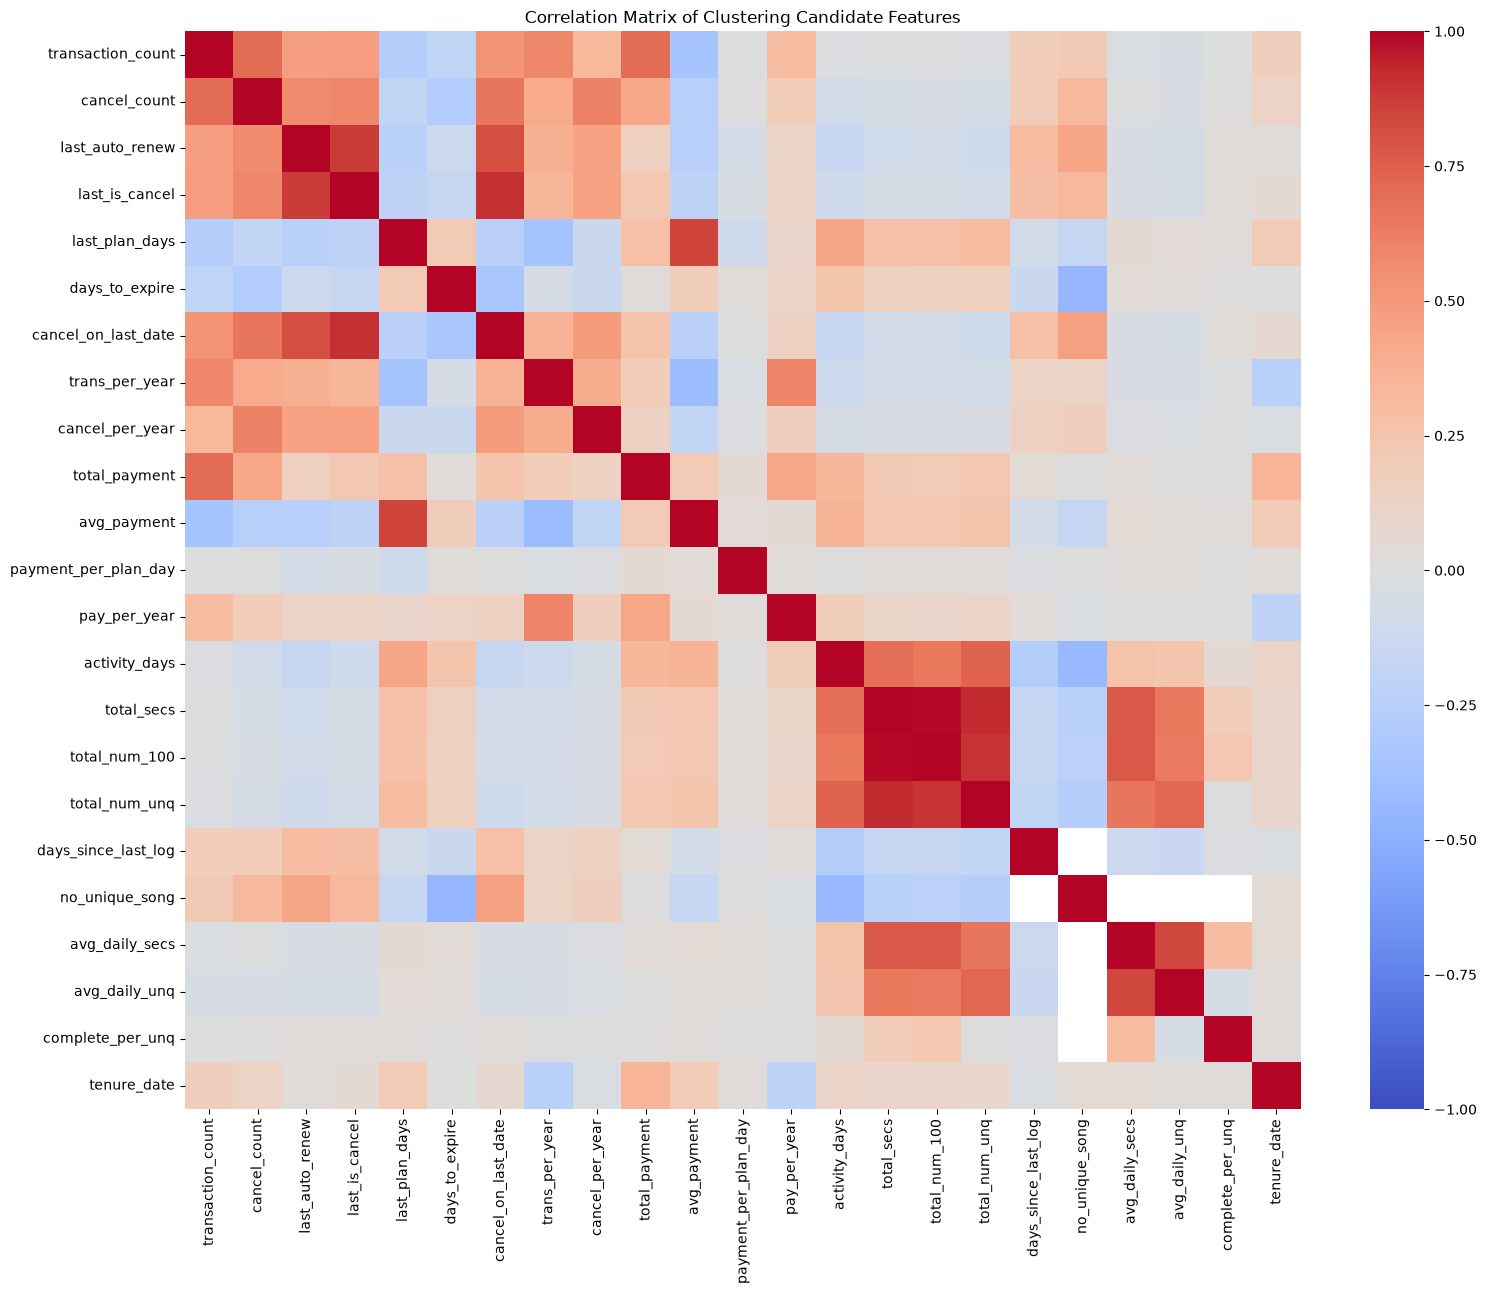

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1
)

plt.title('Correlation Matrix of Clustering Candidate Features')
plt.show()

In [20]:
# 자기 자신 및 중복 조합을 제외하고
# 절댓값 상관계수가 0.8 이상인 변수쌍만 추출

high_corr_pairs = []

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):

        value = corr.iloc[i, j]

        if abs(value) >= 0.8:
            high_corr_pairs.append([
                corr.columns[i],
                corr.columns[j],
                value
            ])

high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=['feature_1', 'feature_2', 'correlation']
)

high_corr_df = high_corr_df.sort_values(
    'correlation',
    key=abs,
    ascending=False
)

high_corr_df

,feature_1,feature_2,correlation
4,total_secs,total_num_100,0.985933
5,total_secs,total_num_unq,0.927414
2,last_is_cancel,cancel_on_last_date,0.906281
6,total_num_100,total_num_unq,0.898666
0,last_auto_renew,last_is_cancel,0.876600
3,last_plan_days,avg_payment,0.846824
7,avg_daily_secs,avg_daily_unq,0.836528
1,last_auto_renew,cancel_on_last_date,0.815864


#### 클러스터링에 사용할 변수 선정

#### 클러스터링 Feature 선정

이탈 위험 고객을 단순히 이탈 확률에 따라 구분하는 것이 아니라, **거래·구독, 결제, 서비스 이용 등의 행동 패턴에 따라 세분화**하기 위해 클러스터링 변수를 선정하였다.

1. 거래/구독 행동

- `transaction_count`: 전체 거래 횟수
- `cancel_count`: 전체 취소 횟수
- `last_auto_renew`: 마지막 거래의 자동 갱신 여부
- `last_is_cancel`: 마지막 거래의 취소 여부
- `last_plan_days`: 마지막으로 이용한 구독 플랜 기간
- `days_to_expire`: 기준일 대비 구독 만료까지 남은 기간
- `trans_per_year`: 고객 관계 기간을 고려한 연간 거래 빈도
- `cancel_per_year`: 고객 관계 기간을 고려한 연간 취소 빈도

→ 고객의 **구독 유지·갱신·취소 행동**을 파악하기 위해 선정하였다.

2. 결제 행동

- `avg_payment`: 거래당 평균 결제금액
- `payment_per_plan_day`: 구독기간 1일당 결제금액
- `pay_per_year`: 고객 관계 기간을 고려한 연간 결제 규모

→ 단순 누적 결제금액보다는 고객의 **평균적인 결제 수준과 구독 대비 결제 특성**을 파악할 수 있는 변수를 중심으로 선정하였다.

3. 서비스 이용 행동

- `activity_days`: 실제 서비스 이용 일수
- `days_since_last_log`: 마지막 서비스 이용 이후 경과 일수
- `no_unique_song`: 고유곡 이용 여부/수준을 나타내는 변수
- `avg_daily_secs`: 활동일 기준 하루 평균 청취 시간
- `avg_daily_unq`: 활동일 기준 하루 평균 고유곡 청취량
- `complete_per_unq`: 고유곡 대비 완청 비율
- `tenure_date`: 가입 이후 고객 관계 지속 기간

→ 서비스의 **이용 빈도, 최근성, 이용량 및 음악 청취 스타일**을 함께 반영하기 위해 선정하였다.

4. 상관관계를 고려한 변수 정리

상관관계 분석 결과 일부 누적형 변수 사이에서 높은 상관관계가 확인되었다.

- `total_secs` ↔ `total_num_100`: 0.986
- `total_secs` ↔ `total_num_unq`: 0.927
- `total_num_100` ↔ `total_num_unq`: 0.899
- `last_is_cancel` ↔ `cancel_on_last_date`: 0.906

K-Means는 변수 간 거리를 기반으로 군집을 형성하므로 유사한 정보를 나타내는 변수를 여러 개 포함하면 특정 행동 특성이 거리 계산에 과도하게 반영될 수 있다. 따라서 단순 누적량보다 **고객의 행동 특성을 상대적으로 잘 설명할 수 있는 평균·비율·빈도 변수를 우선적으로 활용**하였다.

특히 음악 이용 행동의 경우 `total_num_100`과 `total_num_unq`를 단순히 제거하는 대신 `avg_daily_unq`와 `complete_per_unq`를 활용하였다. 이를 통해 **음악을 얼마나 다양하게 이용하는지(이용 폭)**와 **청취한 곡을 얼마나 완청하는지(청취 깊이)**를 구분하여 반영하고자 하였다.

또한 `last_is_cancel`과 높은 상관관계를 보이는 `cancel_on_last_date`는 중복 정보가 반영되는 것을 방지하기 위해 제외하였다.

5. 군집 생성에서 제외한 변수

`bd`, `gender`, `city`와 같은 인구통계적 변수는 고객의 행동 자체보다는 고객의 특성을 설명하는 변수이므로 군집 생성에는 사용하지 않는다.

대신 클러스터링 완료 후 각 군집의 연령, 성별, 지역 분포를 비교하여 **각 행동 군집의 고객 프로파일을 해석하는 용도**로 활용한다.

또한 `churn_prob`는 이미 이탈 위험 고객을 선별하는 데 사용된 값이므로 클러스터링 변수에서는 제외하고, 군집 생성 이후 각 군집의 평균 이탈 확률을 비교하는 데 활용한다.

In [21]:
cluster_features = [
    # 1. 거래/구독 행동
    'transaction_count',
    'cancel_count',
    'last_auto_renew',
    'last_is_cancel',
    'last_plan_days',
    'days_to_expire',
    'trans_per_year',
    'cancel_per_year',

    # 2. 결제 행동
    'avg_payment',
    'payment_per_plan_day',
    'pay_per_year',

    # 3. 서비스 이용 행동
    'activity_days',
    'days_since_last_log',
    'no_unique_song',
    'avg_daily_secs',
    'avg_daily_unq',
    'complete_per_unq',

    # 4. 고객 관계
    'tenure_date'
]

print("클러스터링 Feature 수:", len(cluster_features))
print(cluster_features)

클러스터링 Feature 수: 18
['transaction_count', 'cancel_count', 'last_auto_renew', 'last_is_cancel', 'last_plan_days', 'days_to_expire', 'trans_per_year', 'cancel_per_year', 'avg_payment', 'payment_per_plan_day', 'pay_per_year', 'activity_days', 'days_since_last_log', 'no_unique_song', 'avg_daily_secs', 'avg_daily_unq', 'complete_per_unq', 'tenure_date']


## clustering을 위한 이탈 위험 고객만 모아둔 X_cluster df 구성

In [22]:
# 선택한 feature만 가져오기

X_cluster = risk_df[cluster_features].copy()

print("Shape:", X_cluster.shape)
X_cluster.head()

Shape: (7515, 18)


,transaction_count,cancel_count,last_auto_renew,last_is_cancel,last_plan_days,days_to_expire,trans_per_year,cancel_per_year,avg_payment,payment_per_plan_day,pay_per_year,activity_days,days_since_last_log,no_unique_song,avg_daily_secs,avg_daily_unq,complete_per_unq,tenure_date
10,5.0,0.0,0.0,0.0,195.0,20.0,2.313054,0.0,596.0,3.056410,1378.580482,89.0,0.0,0,9025.076888,37.730337,0.816855,822.0
20,1.0,0.0,0.0,0.0,30.0,26.0,0.462611,0.0,180.0,6.000000,83.269962,5.0,0.0,0,5152.683400,17.800000,0.988764,1479.0
51,4.0,0.0,0.0,0.0,30.0,6.0,10.735294,0.0,180.0,6.000000,1932.352941,43.0,6.0,0,3381.761953,13.023256,0.996429,136.0
56,1.0,0.0,0.0,0.0,410.0,4.0,0.462611,0.0,1788.0,4.360976,827.148289,89.0,0.0,0,44305.742944,124.876404,1.535721,1430.0
66,5.0,0.0,0.0,0.0,30.0,24.0,2.313054,0.0,214.6,7.153333,496.381496,64.0,3.0,0,7469.222828,14.265625,1.778751,839.0


In [23]:
missing_check = pd.DataFrame({
    'missing_count': X_cluster.isnull().sum(),
    'missing_ratio': X_cluster.isnull().mean()
})

missing_check = missing_check[
    missing_check['missing_count'] > 0
].sort_values('missing_ratio', ascending=False)

missing_check

,missing_count,missing_ratio
complete_per_unq,806,0.107252
days_since_last_log,806,0.107252
avg_daily_secs,806,0.107252
avg_daily_unq,806,0.107252
trans_per_year,314,0.041783
cancel_per_year,314,0.041783
pay_per_year,314,0.041783
tenure_date,314,0.041783
last_auto_renew,138,0.018363
last_is_cancel,138,0.018363


## 결측치 drop

In [24]:
# 클러스터링 Feature가 모두 존재하는 고객만 사용
X_cluster_complete = X_cluster.dropna().copy()

print("기존 위험 고객 수:", len(X_cluster))
print("결측 제거 후 고객 수:", len(X_cluster_complete))
print("제거된 고객 수:", len(X_cluster) - len(X_cluster_complete))
print(
    "제거 비율:",
    f"{(1 - len(X_cluster_complete) / len(X_cluster)):.2%}"
)

기존 위험 고객 수: 7515
결측 제거 후 고객 수: 6696
제거된 고객 수: 819
제거 비율: 10.90%


## X_cluster scaling

기초 통계량 확인

In [25]:
X_cluster_complete.describe().T

,count,mean,std,min,25%,50%,75%,max
transaction_count,6696.0,7.235215,7.623090,1.000000,2.000000,4.000000,10.000000,68.000000
cancel_count,6696.0,0.262246,0.620955,0.000000,0.000000,0.000000,0.000000,10.000000
last_auto_renew,6696.0,0.111858,0.315215,0.000000,0.000000,0.000000,0.000000,1.000000
last_is_cancel,6696.0,0.096476,0.295264,0.000000,0.000000,0.000000,0.000000,1.000000
last_plan_days,6696.0,107.268668,129.673091,1.000000,30.000000,30.000000,180.000000,450.000000
days_to_expire,6696.0,24.317802,57.615913,-665.000000,8.000000,17.000000,25.000000,892.000000
trans_per_year,6696.0,5.612069,5.719976,0.462611,1.387833,3.882979,9.177581,206.725664
cancel_per_year,6696.0,0.186426,0.647427,0.000000,0.000000,0.000000,0.000000,12.166667
avg_payment,6696.0,403.220647,479.660437,0.000000,149.000000,180.000000,456.500000,1788.000000
payment_per_plan_day,6696.0,5.494087,13.509196,0.000000,3.333333,4.598765,4.991898,894.000000


In [26]:
skewness = X_cluster_complete.skew().sort_values(ascending=False)

skewness

payment_per_plan_day    46.230525
complete_per_unq        16.036264
cancel_per_year         10.514904
trans_per_year           8.625593
days_to_expire           5.429131
pay_per_year             5.249295
days_since_last_log      5.162700
cancel_count             3.452244
avg_daily_secs           2.914179
avg_daily_unq            2.772891
last_is_cancel           2.734127
last_auto_renew          2.463450
avg_payment              2.002465
transaction_count        1.740686
last_plan_days           1.545281
tenure_date              1.243097
activity_days            0.322032
no_unique_song           0.000000
dtype: float64

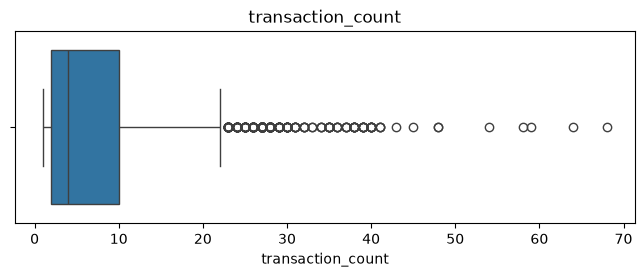

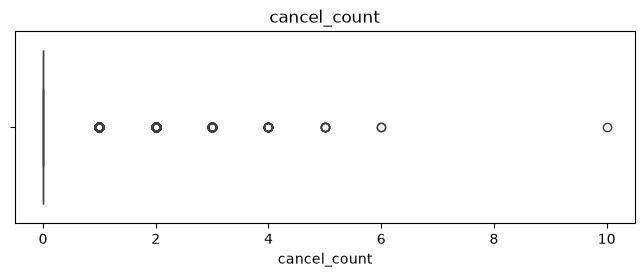

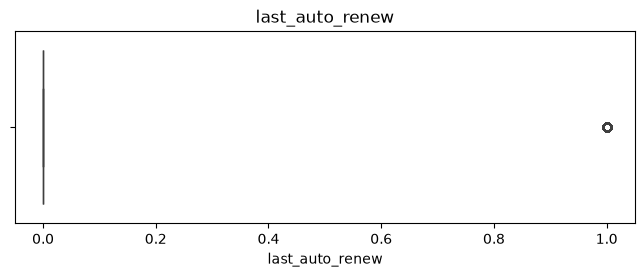

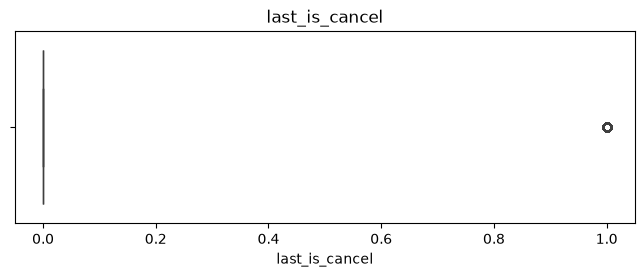

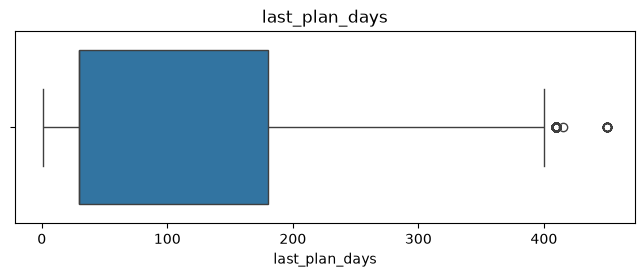

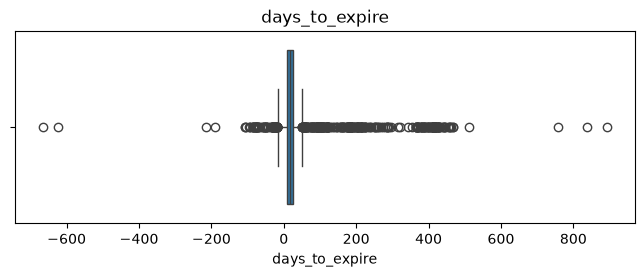

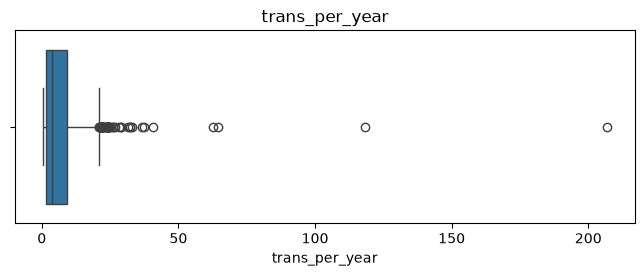

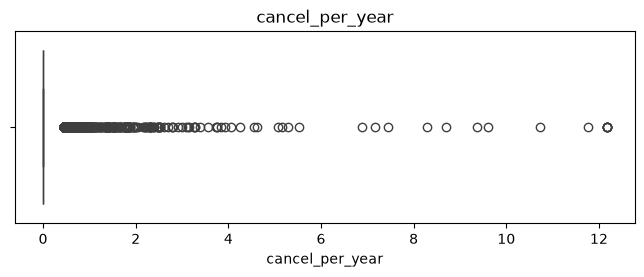

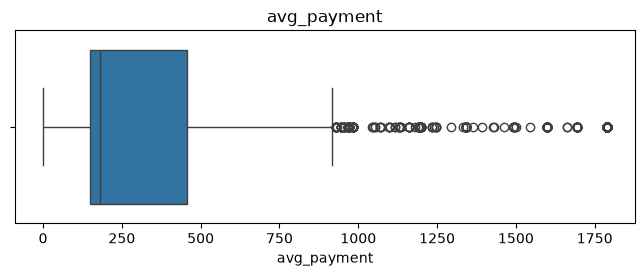

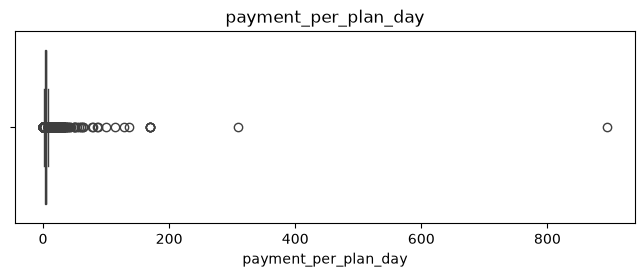

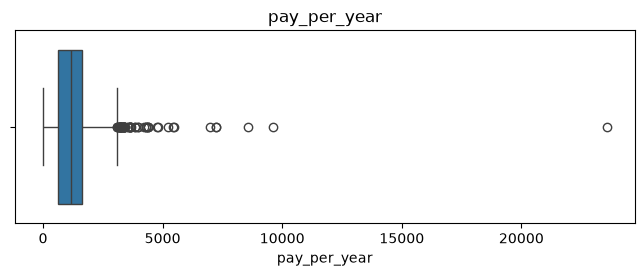

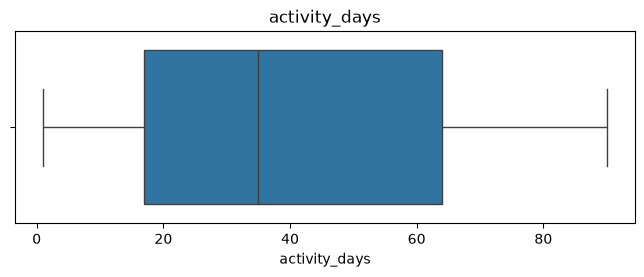

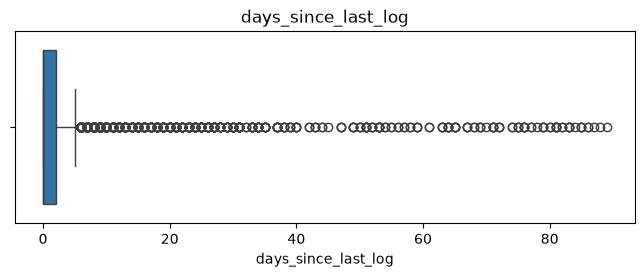

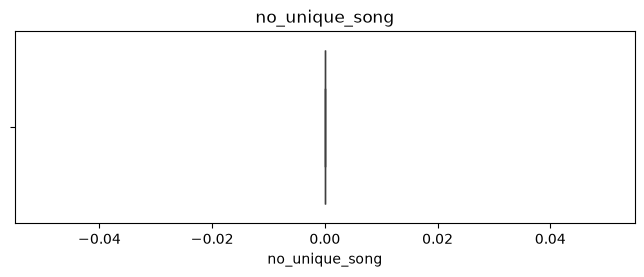

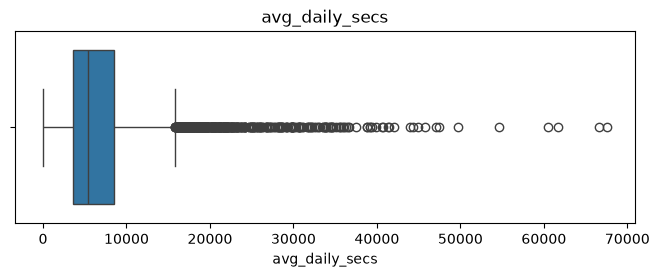

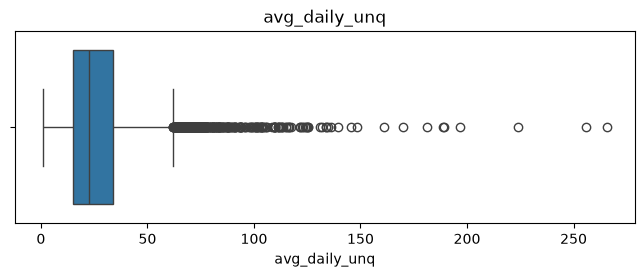

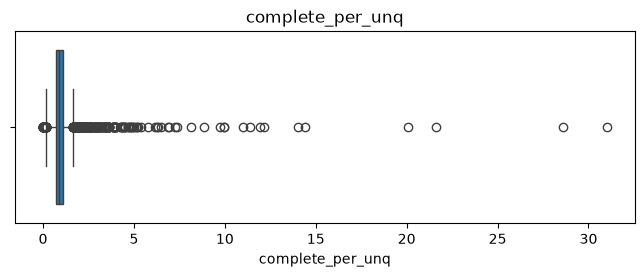

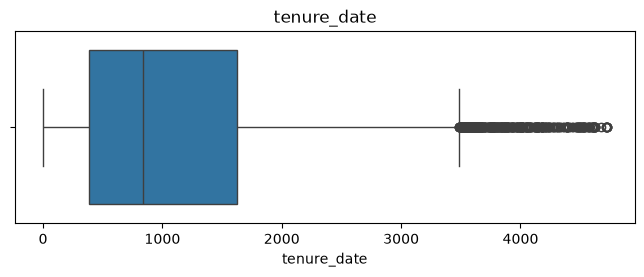

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in cluster_features:
    plt.figure(figsize=(8, 2.5))
    
    sns.boxplot(
        x=X_cluster_complete[col]
    )
    
    plt.title(col)
    plt.show()

In [28]:
# 왜도 2보다 크면 심하게 치우친 데이터라고 판단 -> log 변환 (이진분류 변수는 제외)

# 왜도가 1보다 큰 변수 확인
log_candidates = skewness[skewness > 1].index.tolist()

print("로그 변환 후보:")
print(log_candidates)

로그 변환 후보:
['payment_per_plan_day', 'complete_per_unq', 'cancel_per_year', 'trans_per_year', 'days_to_expire', 'pay_per_year', 'days_since_last_log', 'cancel_count', 'avg_daily_secs', 'avg_daily_unq', 'last_is_cancel', 'last_auto_renew', 'avg_payment', 'transaction_count', 'last_plan_days', 'tenure_date']


In [29]:
binary_features = [
    'last_auto_renew',
    'last_is_cancel',
    'no_unique_song'
]

log_features = [
    col for col in log_candidates
    if col not in binary_features
]

print("최종 로그 변환 대상:")
print(log_features)

최종 로그 변환 대상:
['payment_per_plan_day', 'complete_per_unq', 'cancel_per_year', 'trans_per_year', 'days_to_expire', 'pay_per_year', 'days_since_last_log', 'cancel_count', 'avg_daily_secs', 'avg_daily_unq', 'avg_payment', 'transaction_count', 'last_plan_days', 'tenure_date']


In [30]:
X_cluster_complete[log_features].min()

payment_per_plan_day      0.000000
complete_per_unq          0.000000
cancel_per_year           0.000000
trans_per_year            0.462611
days_to_expire         -665.000000
pay_per_year              0.000000
days_since_last_log       0.000000
cancel_count              0.000000
avg_daily_secs            1.882000
avg_daily_unq             1.000000
avg_payment               0.000000
transaction_count         1.000000
last_plan_days            1.000000
tenure_date               0.000000
dtype: float64

In [31]:
# 음수 값이 있는 feature는 log 변환 대상에서 제외

log_features = [
    col for col in log_features
    if X_cluster_complete[col].min() >= 0
]

print(log_features)

['payment_per_plan_day', 'complete_per_unq', 'cancel_per_year', 'trans_per_year', 'pay_per_year', 'days_since_last_log', 'cancel_count', 'avg_daily_secs', 'avg_daily_unq', 'avg_payment', 'transaction_count', 'last_plan_days', 'tenure_date']


In [32]:
# 로그 변환
X_cluster_transformed = X_cluster_complete.copy()

for col in log_features:
    X_cluster_transformed[col] = np.log1p(
        X_cluster_transformed[col]
    )

In [33]:
# 변환 후 왜도 검정
skew_before = X_cluster_complete[log_features].skew()
skew_after = X_cluster_transformed[log_features].skew()

skew_compare = pd.DataFrame({
    'before': skew_before,
    'after': skew_after
})

skew_compare

,before,after
payment_per_plan_day,46.230525,1.102145
complete_per_unq,16.036264,2.259102
cancel_per_year,10.514904,3.236838
trans_per_year,8.625593,0.033069
pay_per_year,5.249295,-2.240004
days_since_last_log,5.162700,1.466840
cancel_count,3.452244,2.001217
avg_daily_secs,2.914179,-0.990053
avg_daily_unq,2.772891,-0.252213
avg_payment,2.002465,0.005774


#### 로그변환 전후 비교하여, 로그 변환할 feature 최종 선정
- 로그 변환 후 오히려 왜도가 과도하게 음수로 변한 pay_per_year, tenure_date는 과도한 변환을 방지하기 위해 원본으로 복원하였다.  
- complete_per_unq는 고객의 완청 성향을 나타내는 비율형 변수로, 원래 값의 상대적 차이와 해석 가능성을 유지하기 위해 원본을 사용하였다.  
- 반면 cancel_count, cancel_per_year처럼 극단값의 영향을 줄이는 것이 중요한 횟수·빈도형 변수는 로그 변환을 유지하였다.

In [34]:
# 원본으로 되돌릴 변수
restore_features = [
    'complete_per_unq',
    'pay_per_year',
    'tenure_date'
]

for col in restore_features:
    X_cluster_transformed[col] = X_cluster_complete[col]

## scaling

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scaling
X_scaled = scaler.fit_transform(X_cluster_transformed)

# 다시 DataFrame으로 변환
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X_cluster_transformed.columns,
    index=X_cluster_transformed.index
)

X_scaled.head()

,transaction_count,cancel_count,last_auto_renew,last_is_cancel,last_plan_days,days_to_expire,trans_per_year,cancel_per_year,avg_payment,payment_per_plan_day,pay_per_year,activity_days,days_since_last_log,no_unique_song,avg_daily_secs,avg_daily_unq,complete_per_unq,tenure_date
10,0.059801,-0.470109,-0.354889,-0.326767,1.162621,-0.074947,-0.503582,-0.423147,0.927123,-0.574010,0.337253,1.786960,-0.704901,0.0,0.678940,0.820382,-0.204686,-0.326710
20,-1.242603,-0.470109,-0.354889,-0.326767,-0.666599,0.029199,-1.546340,-0.423147,-0.340938,0.527912,-1.428699,-1.300651,-0.704901,0.0,-0.054901,-0.348086,-0.014882,0.292034
51,-0.156341,-0.470109,-0.354889,-0.326767,-0.666599,-0.317953,1.109347,-0.423147,-0.340938,0.527912,1.092234,0.096126,1.202924,0.0,-0.606217,-0.821994,-0.006419,-0.972766
56,-1.242603,-0.470109,-0.354889,-0.326767,1.897114,-0.352669,-1.546340,-0.423147,2.093259,-0.010847,-0.414538,1.786960,-0.704901,0.0,2.762348,2.725903,0.589012,0.245887
66,0.059801,-0.470109,-0.354889,-0.326767,-0.666599,-0.005516,-0.503582,-0.423147,-0.155069,0.835936,-0.865486,0.868028,0.654261,0.0,0.431195,-0.684761,0.857341,-0.310700


In [36]:
pd.options.display.float_format = '{:.4f}'.format

In [37]:
# scaling 잘 됐는지 확인해보기 (평균은 0, 표준편차는 1로 맞춰져 있어야 한다.)
scaling_check = pd.DataFrame({
    'mean': X_scaled.mean(),
    'std': X_scaled.std()
})

scaling_check

,mean,std
transaction_count,-0.0000,1.0001
cancel_count,0.0000,1.0001
last_auto_renew,-0.0000,1.0001
last_is_cancel,0.0000,1.0001
last_plan_days,-0.0000,1.0001
days_to_expire,0.0000,1.0001
trans_per_year,-0.0000,1.0001
cancel_per_year,0.0000,1.0001
avg_payment,0.0000,1.0001
payment_per_plan_day,-0.0000,1.0001


In [38]:
X_scaled = X_scaled.drop(columns=['no_unique_song'])

print(X_scaled.shape)

(6696, 17)


# K-means Clustering

### 적절한 K 탐색하기
- Method 1: Elbow Method
- Method 2: Silhouette Score

#### Elbow Method와 Silhouette Score

- **Elbow Method**
  - K(군집 개수)를 증가시키면서 **군집 내부의 데이터들이 얼마나 가깝게 모여 있는지(Inertia)**를 확인하는 방법
  - K가 증가할수록 Inertia는 감소하지만, **감소 폭이 급격히 줄어드는 지점(팔꿈치처럼 꺾이는 지점)**을 적절한 K로 판단한다.

- **Silhouette Score**
  - 같은 군집의 데이터끼리는 얼마나 가깝고, **다른 군집과는 얼마나 잘 분리되어 있는지**를 평가하는 지표
  - 값의 범위는 **-1 ~ 1**이며, **1에 가까울수록 군집이 잘 형성되었다고 판단**한다.

→ 따라서 **Elbow Method로 적절한 K의 범위를 찾고, Silhouette Score를 함께 비교하여 최종 군집 개수를 결정**한다.

In [39]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 11)

inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    # Elbow Method
    inertias.append(kmeans.inertia_)
    
    # Silhouette Score
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

Elbow Method 그래프

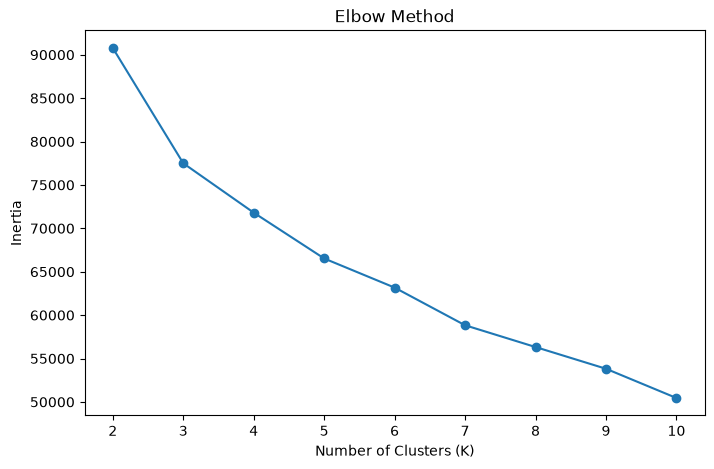

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    k_range,
    inertias,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.xticks(list(k_range))
plt.show()

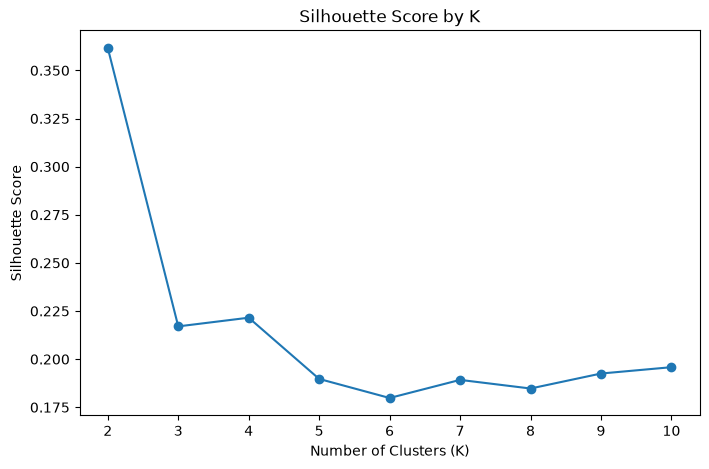

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_range,
    silhouette_scores,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by K')

plt.xticks(list(k_range))
plt.show()

### 최종 군집 수 선정: K = 4

- Silhouette Score는 K=2에서 가장 높았으나, 이탈 위험 고객을 다양한 행동 유형으로 세분화하기에는 군집 수가 지나치게 적다고 판단하였다.
- K=3 이상에서는 K=4의 Silhouette Score가 가장 높고 Elbow Method에서도 군집 내 오차가 지속적으로 감소하므로, **군집 품질과 고객 세분화의 해석 가능성을 함께 고려하여 K=4로 선정하였다.**

## K-means clustering 진행 (k=4)

In [42]:
from sklearn.cluster import KMeans

# 최종 K-Means 모델
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10 #10개의 서로 다른 초기 중심점에서 K-means clustering 수행한 후 가장 좋은 점 선정
)

# 군집 학습 + 각 고객의 군집 번호 생성
cluster_labels = kmeans.fit_predict(X_scaled)

# 군집 번호 확인
cluster_labels[:20]

array([2, 0, 0, 2, 0, 0, 0, 2, 2, 2, 1, 1, 2, 0, 2, 3, 0, 0, 3, 2],
      dtype=int32)

## 클러스터링 결과를 risk_df에 넣어서 행동 패턴 데이터 함께 볼 수 있도록 하자

In [43]:
# 클러스터링에 실제 사용된 고객 데이터
clustered_customers = risk_df.loc[X_scaled.index].copy()

# 군집 번호 추가
clustered_customers['cluster'] = cluster_labels

clustered_customers.head()

,msno,is_churn,city,bd,gender,registered_via,registration_init_time,transaction_count,cancel_count,total_payment,...,data_group,no_unique_song,zero_plan_days,avg_payment,avg_daily_secs,avg_daily_complete,avg_daily_unq,complete_per_unq,payment_per_plan_day,cluster
10,u8lfEQgLV1Gfxa0dSoPkwgp3w9F7YUAmmhT0HCfP6/g=,1,13.0000,21.0000,male,9,2014-11-29,5.0000,0.0000,2980.0000,...,둘 다 있음,0,0,596.0000,9025.0769,30.8202,37.7303,0.8169,3.0564,2
20,W+HrX2Pwbi0KnVxNIJngvTBHZqcIOjOnyXnHmm90R44=,0,15.0000,35.0000,male,3,2013-02-10,1.0000,0.0000,180.0000,...,둘 다 있음,0,0,180.0000,5152.6834,17.6000,17.8000,0.9888,6.0000,0
51,0J9+B6xRVQlJhmbVqo4fvDJHCIHH1YEb3JHnj6/caH4=,0,1.0000,0.0000,NaN,4,2016-10-15,4.0000,0.0000,720.0000,...,둘 다 있음,0,0,180.0000,3381.7620,12.9767,13.0233,0.9964,6.0000,0
56,SINxfCO42vHSolOLODK6BACG6EYzcH8EPZVAY46fGFY=,1,6.0000,23.0000,female,3,2013-03-31,1.0000,0.0000,1788.0000,...,둘 다 있음,0,0,1788.0000,44305.7429,191.7753,124.8764,1.5357,4.3610,2
66,EKk4RJ/F5ZLvslye+ZrhVYVfquSTSggEKfoCW/xK9fM=,0,5.0000,28.0000,male,3,2014-11-12,5.0000,0.0000,1073.0000,...,둘 다 있음,0,0,214.6000,7469.2228,25.3750,14.2656,1.7788,7.1533,0


In [44]:
cluster_count = clustered_customers['cluster'].value_counts().sort_index()

cluster_ratio = (
    clustered_customers['cluster']
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

cluster_summary = pd.DataFrame({
    'customer_count': cluster_count,
    'ratio(%)': cluster_ratio
})

cluster_summary

,customer_count,ratio(%)
cluster,,
0,3437,51.3292
1,681,10.1703
2,1748,26.1051
3,830,12.3955


## 군집화 결과 해석하는 Cluster Profiling

In [45]:
# 클러스터링에 사용했던 원본 Feature + cluster
cluster_profile = X_cluster_complete.copy()

# 동일한 index 순서로 cluster label 추가
cluster_profile['cluster'] = cluster_labels

# 군집별 평균
cluster_mean = cluster_profile.groupby('cluster').mean()

cluster_mean.T

cluster,0,1,2,3
transaction_count,5.3640,18.0162,2.6482,15.7988
cancel_count,0.0131,1.3612,0.0040,0.9361
last_auto_renew,0.0070,0.9956,0.0000,0.0566
last_is_cancel,0.0000,0.9486,0.0000,0.0000
last_plan_days,33.5420,29.9001,275.0543,122.6867
days_to_expire,18.7928,4.4479,34.8827,41.2494
trans_per_year,5.6000,11.0543,1.6168,9.6111
cancel_per_year,0.0065,1.0612,0.0019,0.6027
avg_payment,197.5296,125.6978,1020.9046,181.8250
payment_per_plan_day,7.2236,4.2485,3.8464,2.8245


In [46]:
cluster_median = (
    cluster_profile
    .groupby('cluster')
    .median()
)

cluster_median.T

cluster,0,1,2,3
transaction_count,4.0000,19.0000,2.0000,14.0000
cancel_count,0.0000,1.0000,0.0000,1.0000
last_auto_renew,0.0000,1.0000,0.0000,0.0000
last_is_cancel,0.0000,1.0000,0.0000,0.0000
last_plan_days,30.0000,30.0000,195.0000,90.0000
days_to_expire,17.0000,1.0000,18.0000,20.0000
trans_per_year,4.2442,12.2294,1.3878,8.3270
cancel_per_year,0.0000,0.8184,0.0000,0.4626
avg_payment,149.0000,130.3750,894.0000,159.6744
payment_per_plan_day,4.9667,4.3458,4.2873,2.4419


In [47]:
clustered_customers = clustered_customers.merge(
    risk_customers[['msno', 'churn_prob']],
    on='msno',
    how='left'
)

In [48]:
clustered_customers.groupby('cluster').agg(
    customer_count=('msno', 'count'),
    avg_churn_prob=('churn_prob', 'mean'),
    actual_churn_rate=('is_churn', 'mean')
)

,customer_count,avg_churn_prob,actual_churn_rate
cluster,,,
0,3437,0.4518,0.5161
1,681,0.7373,0.7577
2,1748,0.8443,0.8627
3,830,0.5696,0.6373


## K-Means 군집별 특성 해석

K=4로 클러스터링한 결과, 각 군집은 거래·구독 패턴, 서비스 이용 수준, 이탈 위험도에서 서로 다른 특징을 보였다.  
군집의 특성은 평균과 중앙값을 함께 비교하여 해석하였으며, `churn_prob`와 실제 이탈률은 클러스터링에는 사용하지 않고 군집 생성 이후 위험 수준을 해석하는 지표로 활용하였다.

### Cluster 0 — 저활동·단기 구독형

- **3,437명으로 전체의 약 51.3%**를 차지하는 가장 큰 군집
- 거래 횟수 중앙값은 4회, 연간 거래 횟수도 약 4.24회로 비교적 낮음
- 마지막 플랜 기간의 중앙값이 **30일**로 단기 구독 중심
- 활동일 중앙값이 **22일**로 네 군집 중 가장 낮고, 하루 평균 청취시간과 고유곡 이용량 역시 가장 낮은 수준
- 평균 이탈확률은 **45.2%**, 실제 이탈률은 **51.6%**로 네 군집 중 가장 낮음

→ 서비스 이용과 거래 활동이 전반적으로 낮은 **저활동·단기 구독 고객군**으로 볼 수 있다. 이탈 위험 고객으로 선별되기는 했지만 다른 군집과 비교하면 상대적인 이탈 위험도는 가장 낮다.

---

### Cluster 1 — 반복 거래·취소 위험형

- **681명으로 약 10.2%**를 차지
- 거래 횟수 중앙값이 **19회**, 연간 거래 횟수도 약 **12.23회**로 매우 높음
- 취소 횟수 중앙값이 1회이고 `last_is_cancel` 중앙값이 **1**로, 마지막 거래에서 실제 취소한 고객이 집중되어 있음
- `last_auto_renew` 역시 대부분 1로 나타나 자동갱신을 사용하면서도 취소 행동이 발생하는 특징을 보임
- 마지막 플랜 기간 중앙값은 **30일**로 단기 플랜 중심
- 마지막 로그 이후 경과일 중앙값이 **4일**로 다른 군집보다 길어 최근 서비스 활동도 상대적으로 감소
- 평균 이탈확률 **73.7%**, 실제 이탈률 **75.8%**

→ 거래 자체는 활발하지만 **반복적인 갱신·취소 행동과 최근 이용 감소가 함께 나타나는 고객군**이다. 실제 취소 행동이 명확하게 나타나는 만큼 적극적인 이탈 방어가 필요한 집단으로 해석할 수 있다.

---

### Cluster 2 — 장기 플랜·고결제 고위험형

- **1,748명으로 약 26.1%**를 차지
- 거래 횟수 중앙값은 **2회**로 가장 낮지만 마지막 플랜 기간 중앙값이 **195일**로 가장 길음
- 평균 결제금액 중앙값이 **894**로 다른 군집보다 매우 높음
- 활동일 중앙값도 **65일**로 가장 높아 서비스 이용 자체는 활발함
- 취소 횟수와 최근 취소 행동은 거의 나타나지 않음
- 그럼에도 평균 이탈확률이 **84.4%**, 실제 이탈률이 **86.3%**로 네 군집 중 가장 높음

→ 단순한 저활동 고객이 아니라 **장기 플랜을 이용하고 결제 및 서비스 활동 수준도 높은데 이탈 위험이 가장 높은 고객군**이다. 따라서 이 군집은 특히 주의해서 볼 필요가 있으며, 어떤 변수가 높은 이탈 위험을 발생시키는지 추가 분석이 필요한 핵심 고객군이다.

---

### Cluster 3 — 장기 관계·고빈도 거래형

- **830명으로 약 12.4%**를 차지
- 거래 횟수 중앙값이 **14회**, 연간 거래 횟수 약 **8.33회**로 거래 빈도가 높음
- 마지막 플랜 기간 중앙값은 **90일**로 Cluster 0·1보다 장기 플랜을 이용
- 연간 결제금액 중앙값이 약 **1,467**로 네 군집 중 가장 높음
- 활동일 중앙값도 **59일**로 높고 최근까지 서비스를 이용하는 경향을 보임
- 고객 관계 기간 중앙값 역시 약 **1,186일**로 장기 고객 중심
- 평균 이탈확률 **57.0%**, 실제 이탈률 **63.7%**

→ 오랜 기간 서비스를 이용하면서 거래·결제·서비스 활동이 모두 비교적 활발한 **장기 관계·고빈도 거래 고객군**으로 해석할 수 있다. 다만 일정 수준의 취소 경험이 존재하며 실제 이탈률도 63.7%로 나타나 유지 전략이 필요한 집단이다.

---

### 군집별 종합 비교

| Cluster | 주요 특징 | 평균 이탈확률 | 실제 이탈률 |
|---|---|---:|---:|
| **0** | 저활동·단기 구독형 | 45.2% | 51.6% |
| **1** | 반복 거래·취소 위험형 | 73.7% | 75.8% |
| **2** | 장기 플랜·고결제 고위험형 | **84.4%** | **86.3%** |
| **3** | 장기 관계·고빈도 거래형 | 57.0% | 63.7% |

→ 이탈 위험 고객 내부에서도 동일한 행동 패턴이 나타나는 것이 아니라, **저활동형, 취소 행동형, 장기 플랜·고결제형, 장기 관계·고빈도 거래형** 등 서로 다른 유형이 존재함을 확인하였다.  
특히 Cluster 2는 높은 서비스 이용 및 결제 수준에도 불구하고 가장 높은 이탈률을 보였다는 점에서, 단순히 '서비스를 적게 이용하는 고객이 이탈한다'고 해석하기보다는 **군집별로 서로 다른 이탈 원인을 파악하고 차별화된 유지 전략을 설계할 필요가 있다.**

## 군집별 맞춤 마케팅 전략

클러스터링 결과를 바탕으로 모든 이탈 위험 고객에게 동일한 혜택을 제공하기보다, **각 군집의 행동 특성과 이탈 위험 수준에 따라 차별화된 유지 전략**을 제안한다.

### Cluster 0 — 저활동·단기 구독형

**주요 특징**
- 서비스 활동량과 거래 빈도가 전반적으로 낮음
- 30일 단기 플랜 이용 중심
- 네 군집 중 상대적으로 이탈 위험이 가장 낮음

**마케팅 전략: 서비스 이용 활성화**
- 최근 이용 콘텐츠를 기반으로 한 **개인화 음악 추천 및 플레이리스트 제공**
- 일정 기간 미접속 시 **앱 재방문 유도 메시지** 발송
- 연속 이용, 신규 콘텐츠 청취 등 **서비스 이용을 유도하는 미션형 프로모션** 제공

→ 직접적인 할인보다는 **서비스 이용 빈도와 습관을 높여 자연스럽게 구독을 유지하도록 유도**하는 전략이 적합하다.

---

### Cluster 1 — 반복 거래·취소 위험형

**주요 특징**
- 거래 및 자동갱신 빈도가 높지만 취소 행동도 빈번함
- 마지막 거래에서 실제 취소한 고객의 비중이 높음
- 평균 이탈확률 73.7%, 실제 이탈률 75.8%

**마케팅 전략: 취소 직전 이탈 방어**
- 취소 시도 시 **개인화된 할인·무료 이용기간 연장 등 즉각적인 Retention Offer** 제공
- 취소 화면에서 **일시정지(Pause) 또는 저가 플랜 전환**과 같은 대안 제시
- 반복 취소 고객에게 취소 사유를 수집하여 **가격·콘텐츠·이용경험 등 원인별 맞춤 혜택** 제공

→ 이미 명확한 취소 행동이 나타나는 고객군이므로 일반적인 광고보다 **취소 시점에 직접 개입하는 이탈 방어 전략**이 중요하다.

---

### Cluster 2 — 장기 플랜·고결제 고위험형

**주요 특징**
- 장기 플랜과 높은 평균 결제금액
- 서비스 활동 수준도 높음
- 그럼에도 평균 이탈확률 84.4%, 실제 이탈률 86.3%로 가장 위험한 군집

**마케팅 전략: 고가치 고객 집중 유지**
- 이탈 가능성이 높아지는 시점에 **선제적인 갱신 혜택 및 장기구독 할인** 제공
- 장기·고결제 고객을 대상으로 **VIP 혜택, 독점 콘텐츠, 선공개 콘텐츠 등 차별화된 보상** 제공
- 만료일 이전에 개인화된 **재구독/갱신 캠페인**을 집중적으로 실행
- 이탈 시 손실 가치가 큰 고객군이므로 다른 군집보다 **Retention 마케팅 예산을 우선 배분**

→ 단순 이용 활성화보다 **높은 고객가치를 유지하고 장기 플랜 종료 후 이탈하지 않도록 선제적으로 관리**하는 전략이 적합하다.

---

### Cluster 3 — 장기 관계·고빈도 거래형

**주요 특징**
- 장기간 서비스를 이용한 기존 고객
- 거래·결제·서비스 이용 모두 활발함
- 높은 연간 결제 수준을 보이지만 일정 수준의 취소 경험이 존재함

**마케팅 전략: 장기 충성도 강화**
- 가입 기간과 이용 실적에 따른 **장기 고객 Loyalty Reward** 제공
- 장기 고객 전용 할인, 멤버십 등급, 특별 콘텐츠 등 **충성 고객 혜택 강화**
- 누적 이용기간·청취 기록 등을 활용한 **개인화 리캡(Recap) 콘텐츠** 제공
- 장기 고객의 이탈 징후가 발생하면 추가 혜택을 제공하여 관계 유지

→ 이미 서비스와의 관계가 강한 고객이므로 단기적인 할인보다 **장기 이용에 대한 보상과 고객 충성도 강화**에 초점을 맞추는 것이 적합하다.

---

### 군집별 전략 요약

| Cluster | 고객 유형 | 핵심 전략 | 주요 목표 |
|---|---|---|---|
| **0** | 저활동·단기 구독형 | 개인화 추천·재방문 유도 | **이용 활성화** |
| **1** | 반복 거래·취소 위험형 | 취소 시점 Retention Offer | **즉각적 이탈 방어** |
| **2** | 장기 플랜·고결제 고위험형 | VIP·선제적 갱신 혜택 | **고가치 고객 유지** |
| **3** | 장기 관계·고빈도 거래형 | Loyalty Reward·장기 고객 혜택 | **충성도 강화** |

→ 이를 통해 이탈 위험 고객에게 일괄적인 할인 혜택을 제공하는 대신, **Cluster 0은 이용 활성화, Cluster 1은 취소 방어, Cluster 2는 고가치 고객 유지, Cluster 3은 장기 충성도 강화**라는 차별화된 CRM 전략을 적용할 수 있다.

In [49]:
CLUSTER_NAMES = {
    0: "저활동·단기 구독형",
    1: "반복 거래·취소 위험형",
    2: "장기 플랜·고결제 고위험형",
    3: "장기 관계·고빈도 거래형",
}

cluster_bundle = {
    "scaler": scaler,
    "kmeans": kmeans,
    "features": cluster_features,
    "log_features": [c for c in log_features if c not in restore_features],
    "drop_after_scale": ["no_unique_song"],
    "names": CLUSTER_NAMES,
}
joblib.dump(cluster_bundle, "../../models/cluster_model.joblib")

df_all[["msno"] + cluster_features].to_csv("../../data/processed/cluster_features_all.csv", index=False)